# Riesgo de mercado: VaR, Expected Shortfall y backtesting

**Pregunta.** ¿Qué método de Value at Risk (VaR) habría medido correctamente el riesgo diario de una cartera de acciones chilenas entre 2020 y 2026, incluyendo la caída por la pandemia?

**Datos.** Cartera de pesos iguales en las nueve acciones del IPSA del [notebook 01](01_optimizacion_portafolio.ipynb), con precios diarios entre enero de 2019 y agosto de 2026.

**Método.** Se comparan cuatro métodos de VaR al 99%, cada uno pronosticado día a día con información disponible hasta el día anterior:

| Método | Supuesto principal |
|---|---|
| Simulación histórica | El próximo día se parece a los últimos 250 días |
| Normal paramétrico | Los retornos son normales con media y volatilidad de los últimos 250 días |
| t de Student | Los retornos tienen colas pesadas, estimadas por máxima verosimilitud |
| EWMA de RiskMetrics | La volatilidad cambia en el tiempo y pesa más lo reciente, con lambda de 0,94 |

Cada método se valida con las pruebas de Kupiec y Christoffersen y con el semáforo de Basilea. También se revisa si el Expected Shortfall (ES) anticipa bien la severidad de las pérdidas extremas.

**Resultado principal.** Los retornos tienen colas mucho más pesadas que una normal. La t de Student es el único método que pasa las dos pruebas estadísticas, a cambio de exigir un VaR promedio más alto. Todos los métodos subestiman la pérdida promedio en los días de excepción.

## 1. Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from dsaplicado import datos, portafolio as pf, riesgo as rg
from dsaplicado.graficos import (
    COLORES, CRITICO, NEUTRO, TINTA_SECUNDARIA, TINTA_TENUE, aplicar_estilo, eje_porcentaje,
)

aplicar_estilo()
pd.set_option("display.float_format", "{:.4f}".format)

RAIZ = datos.raiz_repositorio()
FIGURAS = RAIZ / "02_finanzas" / "figuras"
FIGURAS.mkdir(exist_ok=True)

NIVEL_VAR = 0.99      # nivel de Basilea para VaR
NIVEL_ES = 0.975      # nivel de Basilea III (FRTB) para ES
VENTANA = 250         # un año hábil de historia para estimar
NOMBRES = {"historico": "Histórico", "normal": "Normal", "t_student": "t de Student", "ewma": "EWMA"}
COLOR_METODO = dict(zip(NOMBRES, COLORES))

## 2. La cartera

In [2]:
precios = datos.cargar_precios(
    RAIZ / "datos" / "precios_ipsa.csv",
    {**datos.ACCIONES_IPSA, **datos.BENCHMARK_IPSA},
    "2019-01-01", "2026-09-01",
).ffill()

acciones = list(datos.ACCIONES_IPSA.values())
retornos = pf.retornos_simples(precios[acciones]).dropna()
# Pesos iguales con rebalanceo diario: el retorno de la cartera es el promedio simple.
cartera = retornos.mean(axis=1).rename("cartera")

print(f"{len(cartera)} días de retornos, de {cartera.index[0]:%d-%m-%Y} a {cartera.index[-1]:%d-%m-%Y}")

1908 días de retornos, de 03-01-2019 a 31-08-2026


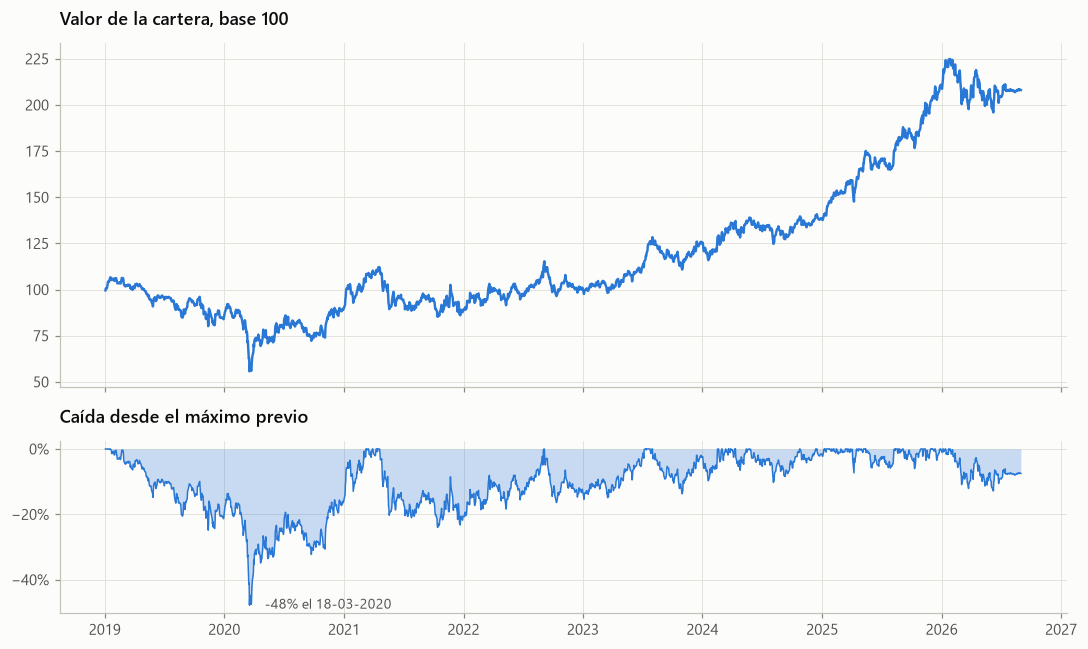

Los cinco peores días:
fecha
2020-03-16    -13.32%
2020-03-18    -11.40%
2021-05-17    -10.13%
2021-12-20     -6.66%
2020-03-12     -5.83%
Name: cartera, dtype: str


In [3]:
valor = 100 * (1 + cartera).cumprod()
caida = pf.serie_drawdown(cartera)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax1.plot(valor.index, valor, color=COLORES[0])
ax1.set_title("Valor de la cartera, base 100")
ax2.fill_between(caida.index, caida, 0, color=COLORES[0], alpha=0.25, linewidth=0)
ax2.plot(caida.index, caida, color=COLORES[0], linewidth=1)
eje_porcentaje(ax2)
ax2.set_title("Caída desde el máximo previo")
fecha_min = caida.idxmin()
ax2.annotate(f"{caida.min():.0%} el {fecha_min:%d-%m-%Y}", (fecha_min, caida.min()), xytext=(10, 0),
             textcoords="offset points", va="center", fontsize=9, color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

print("Los cinco peores días:")
print(cartera.nsmallest(5).map("{:.2%}".format))

La mayor caída ocurrió en marzo de 2020 con la pandemia. Los peores días de la muestra se concentran en esas semanas, lo que ya anticipa que las pérdidas extremas llegan agrupadas.

## 3. ¿Son normales los retornos?

El VaR normal depende de ese supuesto, así que conviene revisarlo antes de usarlo.

In [4]:
gl, loc, escala = rg.ajustar_t(cartera)
jb = stats.jarque_bera(cartera)
pd.Series({
    "asimetría": stats.skew(cartera),
    "exceso de curtosis": stats.kurtosis(cartera),
    "p-valor Jarque-Bera": jb.pvalue,
    "grados de libertad de la t ajustada": gl,
}).to_frame("valor")

,valor
asimetría,-0.4318
exceso de curtosis,10.7094
p-valor Jarque-Bera,0.0000
grados de libertad de la t ajustada,3.7569


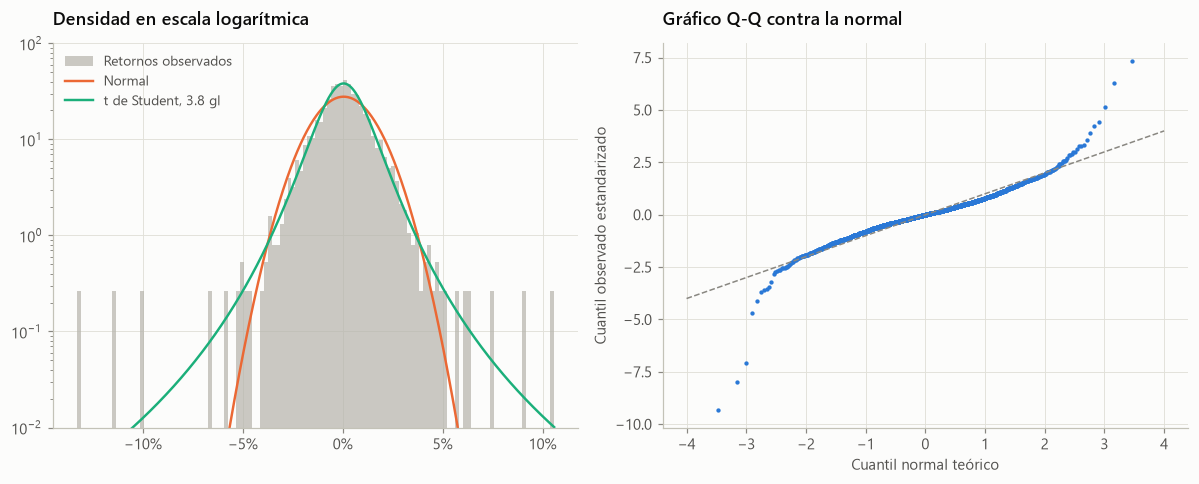

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

x = np.linspace(cartera.min(), cartera.max(), 600)
ax1.hist(cartera, bins=120, density=True, color=NEUTRO, alpha=0.7, label="Retornos observados")
ax1.plot(x, stats.norm.pdf(x, cartera.mean(), cartera.std()), color=COLORES[1], label="Normal")
ax1.plot(x, stats.t.pdf(x, gl, loc, escala), color=COLORES[2], label=f"t de Student, {gl:.1f} gl")
ax1.set_yscale("log"); ax1.set_ylim(1e-2, 100)
eje_porcentaje(ax1, "x")
ax1.set_title("Densidad en escala logarítmica")
ax1.legend(loc="upper left", fontsize=9)

teoricos = stats.norm.ppf((np.arange(1, len(cartera) + 1) - 0.5) / len(cartera))
estandarizados = np.sort((cartera - cartera.mean()) / cartera.std())
ax2.scatter(teoricos, estandarizados, s=8, color=COLORES[0], linewidths=0)
ax2.plot([-4, 4], [-4, 4], color=TINTA_TENUE, linestyle="--", linewidth=1)
ax2.set_xlabel("Cuantil normal teórico"); ax2.set_ylabel("Cuantil observado estandarizado")
ax2.set_title("Gráfico Q-Q contra la normal")
fig.tight_layout()
fig.savefig(FIGURAS / "colas_pesadas.png", bbox_inches="tight")
plt.show()

**Lectura.** El exceso de curtosis es muy alto y la prueba de Jarque-Bera rechaza la normalidad con holgura. En escala logarítmica se ve que la normal asigna probabilidad casi nula a caídas que sí ocurrieron. En el gráfico Q-Q, los puntos de la izquierda se alejan de la diagonal: las peores pérdidas son varias desviaciones estándar más grandes de lo que predice una normal. La t de Student con menos de cuatro grados de libertad describe mucho mejor esas colas.

## 4. VaR y ES con toda la muestra

Primero, una foto estática que usa todos los datos a la vez. Es útil para comparar magnitudes, pero no sirve para validar, porque cada método se ajusta a los mismos datos con que se evalúa.

In [6]:
mu, sigma = cartera.mean(), cartera.std()
vol_actual = rg.volatilidad_ewma(cartera).iloc[-1]
z_var, z_es = stats.norm.ppf(NIVEL_VAR), stats.norm.ppf(NIVEL_ES)

estatico = pd.DataFrame({
    "Histórico": [rg.var_historico(cartera, NIVEL_VAR), rg.es_historico(cartera, NIVEL_ES)],
    "Normal": [rg.var_normal(mu, sigma, NIVEL_VAR), rg.es_normal(mu, sigma, NIVEL_ES)],
    "t de Student": [rg.var_t(gl, loc, escala, NIVEL_VAR), rg.es_t(gl, loc, escala, NIVEL_ES)],
    "EWMA al cierre de la muestra": [z_var * vol_actual, vol_actual * stats.norm.pdf(z_es) / (1 - NIVEL_ES)],
}, index=["VaR 99%", "ES 97,5%"]).T
estatico.style.format("{:.2%}")

,VaR 99%,"ES 97,5%"
Histórico,3.54%,3.99%
Normal,3.29%,3.30%
t de Student,3.75%,4.03%
EWMA al cierre de la muestra,1.05%,1.06%


Con toda la muestra, los métodos histórico y t de Student entregan un VaR mayor que el normal, porque capturan las colas pesadas. El EWMA refleja la volatilidad del momento: al cierre de la muestra el mercado está más tranquilo que el promedio, así que su VaR es menor.

## 5. Backtesting con pronósticos diarios

Ahora cada día se estima el VaR usando solo los 250 días anteriores y se compara con la pérdida realizada ese día. Una **excepción** es un día en que la pérdida supera el VaR pronosticado. Al 99%, se espera una excepción cada 100 días.

Para la t de Student, los grados de libertad se reestiman una vez al mes y la media y la escala se actualizan a diario. Reestimar todo a diario cuesta diez veces más tiempo y cambia muy poco el resultado.

In [7]:
pronosticos = {m: rg.pronosticar_var_es(cartera, m, NIVEL_VAR, VENTANA, recalibrar_cada=21) for m in NOMBRES}
exc = {m: rg.excepciones(cartera, p["var"]) for m, p in pronosticos.items()}

backtest = pd.DataFrame({NOMBRES[m]: rg.resumen_backtest(cartera, p, NIVEL_VAR) for m, p in pronosticos.items()}).T
backtest["var_promedio"] = pd.Series({NOMBRES[m]: p["var"].mean() for m, p in pronosticos.items()})
inicio = pronosticos["historico"].index[0]
print(f"Período evaluado: {inicio:%d-%m-%Y} a {cartera.index[-1]:%d-%m-%Y}")
backtest

Período evaluado: 07-01-2020 a 31-08-2026


,excepciones,esperadas,tasa,p_kupiec,p_christoffersen,excepciones_ultimo_anio,semaforo_ultimo_anio,perdida_media_en_exc,es_medio_en_exc,var_promedio
Histórico,21,16.5800,0.0127,0.2948,0.0269,5,amarilla,0.0465,0.0395,0.0321
Normal,23,16.5800,0.0139,0.1344,0.0396,5,amarilla,0.0459,0.0338,0.0324
t de Student,15,16.5800,0.0090,0.6918,0.1239,2,verde,0.0550,0.0472,0.0362
EWMA,26,16.5800,0.0157,0.0318,0.0068,1,verde,0.0417,0.0342,0.0312


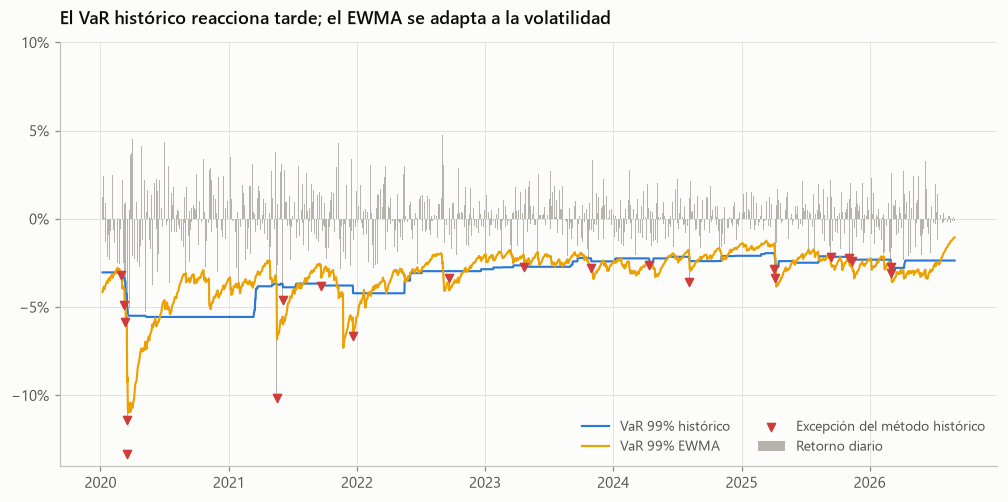

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
r = cartera.loc[inicio:]
ax.bar(r.index, r, width=1.5, color=NEUTRO, label="Retorno diario")
for m in ("historico", "ewma"):
    ax.plot(pronosticos[m].index, -pronosticos[m]["var"], color=COLOR_METODO[m], linewidth=1.4,
            label=f"VaR 99% {NOMBRES[m].lower() if m == 'historico' else NOMBRES[m]}")
dias = exc["historico"].index[exc["historico"] == 1]
ax.scatter(dias, cartera.loc[dias], s=28, color=CRITICO, marker="v", zorder=4,
           label="Excepción del método histórico")
eje_porcentaje(ax)
ax.set_ylim(-0.14, 0.10)
ax.set_title("El VaR histórico reacciona tarde; el EWMA se adapta a la volatilidad")
ax.legend(loc="lower right", fontsize=9, ncols=2)
fig.savefig(FIGURAS / "backtest_var.png", bbox_inches="tight")
plt.show()

El gráfico muestra la diferencia entre los dos enfoques. El VaR histórico queda plano durante meses y salta de golpe cuando un día extremo entra o sale de la ventana. El EWMA sube rápido después de un shock y baja rápido cuando el mercado se calma. Esa rapidez tiene un costo: en días tranquilos queda bajo y un shock repentino lo sorprende.

### Excepciones por año

In [9]:
por_anio = pd.DataFrame({NOMBRES[m]: e.groupby(e.index.year).sum() for m, e in exc.items()})
por_anio["Esperadas"] = cartera.loc[inicio:].groupby(cartera.loc[inicio:].index.year).size() * (1 - NIVEL_VAR)
por_anio.round(1)

,Histórico,Normal,t de Student,EWMA,Esperadas
fecha,,,,,
2020,5,6,5,7,2.5000
2021,4,4,3,5,2.5000
2022,1,0,0,1,2.5000
2023,2,2,1,4,2.5000
2024,2,2,2,4,2.5000
2025,5,7,3,4,2.5000
2026,2,2,1,1,1.7000


### Semáforo de Basilea

El regulador cuenta las excepciones de los últimos 250 días. Con cuatro o menos el modelo está en zona verde. De cinco a nueve pasa a zona amarilla y el banco recibe un recargo de capital. Con diez o más entra en zona roja y el modelo se considera deficiente.

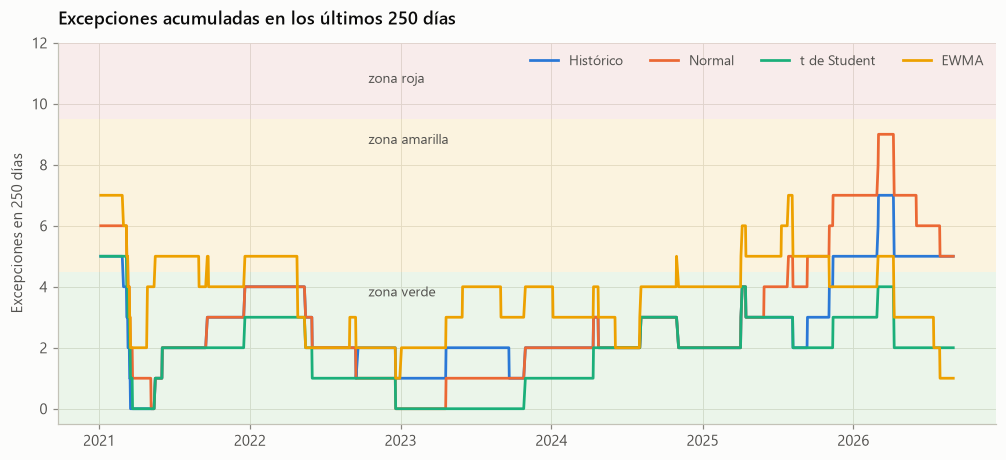

,verde,amarilla,roja,máximo de excepciones
Histórico,83%,17%,0%,7
Normal,79%,21%,0%,9
t de Student,97%,3%,0%,5
EWMA,73%,27%,0%,7


In [10]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axhspan(-0.5, 4.5, color="#0ca30c", alpha=0.07, linewidth=0)
ax.axhspan(4.5, 9.5, color="#fab219", alpha=0.12, linewidth=0)
ax.axhspan(9.5, 12, color="#d03b3b", alpha=0.08, linewidth=0)
conteos = {m: e.rolling(250).sum().dropna() for m, e in exc.items()}
for m, conteo in conteos.items():
    ax.plot(conteo.index, conteo, color=COLOR_METODO[m], linewidth=1.8, label=NOMBRES[m])
x_texto = pd.Timestamp("2022-10-15")  # tramo donde ninguna línea cruza las etiquetas
for texto, y in [("zona verde", 3.8), ("zona amarilla", 8.8), ("zona roja", 10.8)]:
    ax.annotate(texto, (x_texto, y), fontsize=9, color=TINTA_SECUNDARIA, va="center")
ax.set_ylim(-0.5, 12)
ax.set_ylabel("Excepciones en 250 días")
ax.set_title("Excepciones acumuladas en los últimos 250 días")
ax.legend(loc="upper right", ncols=4, fontsize=9)
fig.savefig(FIGURAS / "semaforo_basilea.png", bbox_inches="tight")
plt.show()

zonas = pd.DataFrame({NOMBRES[m]: c.map(rg.semaforo_basilea).value_counts(normalize=True) for m, c in conteos.items()})
zonas = zonas.reindex(["verde", "amarilla", "roja"]).fillna(0).T
zonas.columns.name = None
zonas["máximo de excepciones"] = pd.Series({NOMBRES[m]: c.max() for m, c in conteos.items()})
zonas.style.format({"verde": "{:.0%}", "amarilla": "{:.0%}", "roja": "{:.0%}", "máximo de excepciones": "{:.0f}"})

**Lectura.** Ningún método llega a la zona roja, pero hay diferencias claras. La t de Student pasa muy poco tiempo en zona amarilla, y solo al comienzo, cuando la ventana aún contenía la pandemia. El EWMA es el que más tiempo pasa en amarilla. El normal llegó a nueve excepciones a comienzos de 2026, a una de la zona roja.

## 6. ¿Anticipa el ES la severidad de las pérdidas?

El VaR dice con qué frecuencia se pierde más de cierto umbral, pero no cuánto. Por eso Basilea III reemplazó el VaR por el ES en el cálculo de capital de la cartera de negociación. Una forma simple de revisar el ES es comparar, en los días de excepción, la pérdida realizada con el ES que el modelo había pronosticado para ese día.

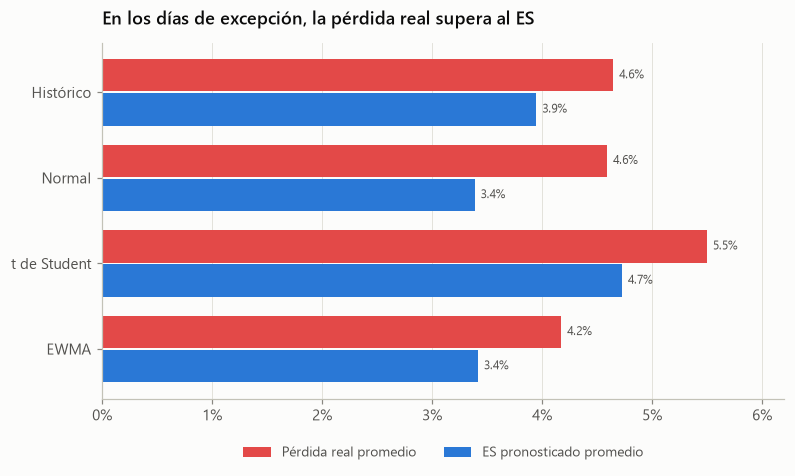

,Pérdida real promedio,ES pronosticado promedio
Histórico,4.65%,3.95%
Normal,4.59%,3.38%
t de Student,5.50%,4.72%
EWMA,4.17%,3.42%


In [11]:
severidad = backtest[["perdida_media_en_exc", "es_medio_en_exc"]].astype(float)
severidad.columns = ["Pérdida real promedio", "ES pronosticado promedio"]

fig, ax = plt.subplots(figsize=(8, 4.2))
y = np.arange(len(severidad))
ax.barh(y - 0.2, severidad["Pérdida real promedio"], height=0.38, color=COLORES[7], label="Pérdida real promedio")
ax.barh(y + 0.2, severidad["ES pronosticado promedio"], height=0.38, color=COLORES[0], label="ES pronosticado promedio")
for i, (real, es) in enumerate(severidad.to_numpy()):
    ax.annotate(f"{real:.1%}", (real, i - 0.2), xytext=(4, 0), textcoords="offset points", va="center", fontsize=8, color=TINTA_SECUNDARIA)
    ax.annotate(f"{es:.1%}", (es, i + 0.2), xytext=(4, 0), textcoords="offset points", va="center", fontsize=8, color=TINTA_SECUNDARIA)
ax.set_yticks(y, severidad.index)
ax.invert_yaxis()
eje_porcentaje(ax, "x", 0)
ax.grid(axis="y", visible=False)
ax.set_title("En los días de excepción, la pérdida real supera al ES")
ax.set_xlim(0, 0.062)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncols=2, fontsize=9)
plt.show()
severidad.style.format("{:.2%}")

## 7. Conclusiones

1. **Los retornos no son normales.** El exceso de curtosis y el gráfico Q-Q muestran colas mucho más pesadas que una normal. Cualquier método que suponga normalidad subestimará las pérdidas extremas.
2. **La t de Student es el único método que pasa ambas pruebas.** Su tasa de excepciones es cercana al 1% esperado y sus excepciones no aparecen agrupadas. El costo es un VaR promedio más alto, lo que implica más capital en uso normal.
3. **El histórico y el normal aciertan en el promedio, pero fallan en el momento.** Pasan la prueba de Kupiec y fallan la de Christoffersen, porque sus excepciones se concentran en episodios de estrés.
4. **El EWMA reacciona rápido, pero con colas normales no alcanza.** Tiene más excepciones de las esperadas y también agrupadas. Su dinámica es correcta, pero multiplica la volatilidad por un cuantil normal que es demasiado pequeño para estos retornos.
5. **Todos los métodos subestiman la severidad.** En los días de excepción, la pérdida real supera en promedio al ES pronosticado, incluso con la t de Student.

## 8. Limitaciones y próximos pasos

- **Una sola cartera y un solo horizonte.** Los resultados dependen de la cartera de pesos iguales y del horizonte de un día. Basilea exige además un horizonte de diez días.
- **Poca potencia estadística.** Con alrededor de 17 excepciones esperadas, las pruebas tienen poca capacidad para distinguir entre modelos parecidos.
- **Combinar volatilidad dinámica con colas pesadas.** El siguiente paso natural es un modelo GARCH con innovaciones t de Student o una simulación histórica filtrada. Ese modelo se desarrolla en el bloque de series de tiempo.
- **Validación completa.** Un repositorio dedicado a la validación de modelos VaR y ES profundizará en backtesting de ES, horizontes de diez días y pruebas de estrés.